# pyEDITH Tutorial: Spectroscopy Mode

This tutorial will guide you through using pyEDITH in spectroscopy mode. We'll explore how to set up parameters, run the Exposure Time Calculator (ETC), and analyze the results for spectroscopic observations.

.. note:: 
If you're new to pyEDITH or need a refresher on basic concepts, please refer to the [Imaging Mode Tutorial](imaging_tutorial.ipynb) first. The imaging tutorial covers fundamental concepts that are also applicable to spectroscopy mode.


## 1. Usage
In this section, we will use the classes previously defined to run spectroscopic noise simulations.

### 1.1 Setup and Imports

First, let's import the necessary modules and set up our environment:


In [1]:
import pyEDITH as pE
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

# Set verbosity to INFO, showing info, warnings and errors. Other options are "warning" (warnings and errors), 
# "quiet" (only errors), and "debug" (all logs)
pE.set_verbosity(level='info') 

# Set the necessary environment variables
# Replace with your paths or add to your .bashrc/.zshrc:
# export SCI_ENG_DIR="/path/to/Sci-Eng-Interface/hwo_sci_eng"
# export YIP_CORO_DIR="/path/to/yips"

# Loading HWO style package to make pretty plots
import hwostyle
hwostyle.use("light")
colors = hwostyle.palette


/Users/ealei/Coding/pyEDITH/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[pyEDITH] INFO [2026-09-17 10:26:24,546] Logging level set to: INFO


We now set up a parameters dictionary. This is where all the input parameters are stored for EDITH.

In [2]:
parameters = {}
parameters["observing_mode"] = "IFS" # tells ETC to use spectroscopy (IFS) mode

### 1.1.1 Observation
We now set up the **Observation** class. Eventually, this is where the exposure time or SNR will be placed after calculation. To set up the observation object, we need to specify a few overarching parameters:


In [3]:
# define a wavelength grid in microns
parameters["wavelength"] = np.linspace(0.2, 1.8, 1000)     

# the SNR you want for each spectral bin 
parameters["snr"] = 7*np.ones_like(parameters["wavelength"]) 

# factor to multiply the background by (used for differential imaging)  
parameters["CRb_multiplier"] = 2.          
                    


We need to then define the filter(s) to be used in the simulation. We can then parse the filter list to ensure that only filters that are fully included in the input wavelength range are considered.

In [4]:
parameters['filter_list']=pE.Filter("VIS",low=0.5,high=1.0, resolution=140,type='IFS')
parsed_filters=pE.parse_input.parse_filters(parameters)
print(parsed_filters[0])


Filter(name='VIS', type='IFS', range=0.500 um-1.000 um, center=0.750 um, R=140)


The `Filter` object determines the wavelength grid to which to rebin all the other quantities. Multiple filters can also be considered (see below).

In [5]:
import pprint 
pprint.pprint(parsed_filters[0].__dict__)

{'bandwidth': <Quantity 0.66666667>,
 'center': <Quantity 0.75 um>,
 'delta_wavelength': <Quantity [0.00357143, 0.00359703, 0.00362282, 0.00364879, 0.00367494,
           0.00370129, 0.00372782, 0.00375454, 0.00378145, 0.00380856,
           0.00383586, 0.00386336, 0.00389105, 0.00391895, 0.00394704,
           0.00397533, 0.00400383, 0.00403253, 0.00406144, 0.00409055,
           0.00411988, 0.00414941, 0.00417916, 0.00420911, 0.00423929,
           0.00426968, 0.00430028, 0.00433111, 0.00436216, 0.00439343,
           0.00442492, 0.00445664, 0.00448859, 0.00452076, 0.00455317,
           0.00458581, 0.00461868, 0.00465179, 0.00468514, 0.00471872,
           0.00475255, 0.00478662, 0.00482093, 0.00485549, 0.0048903 ,
           0.00492535, 0.00496066, 0.00499622, 0.00503203, 0.00506811,
           0.00510444, 0.00514103, 0.00517788, 0.005215  , 0.00525238,
           0.00529003, 0.00532795, 0.00536615, 0.00540461, 0.00544336,
           0.00548238, 0.00552168, 0.00556126, 0.00560113, 

There are more parameters we can define (see below), but these are the basics for now. With these parameters, we can populate the Observation class.



In [6]:
observation = pE.Observation() 

# load the specified configuration in the parameters dict 
observation.load_configuration(parameters, filter=parsed_filters[0]) 
observation.set_output_arrays()
observation.validate_configuration()



[pyEDITH] INFO [2026-09-17 10:26:24,564] 'snr' has length 1000 but the resolved wavelength grid has length 98. Rebinning...


### 1.1.2 Astrophysical Scene
Up next, the **Astrophysical Scene** object. We will use a blackbody spectrum for a Solar-like star and a template for an Earth-like reflectance spectrum for the purposes of this tutorial.

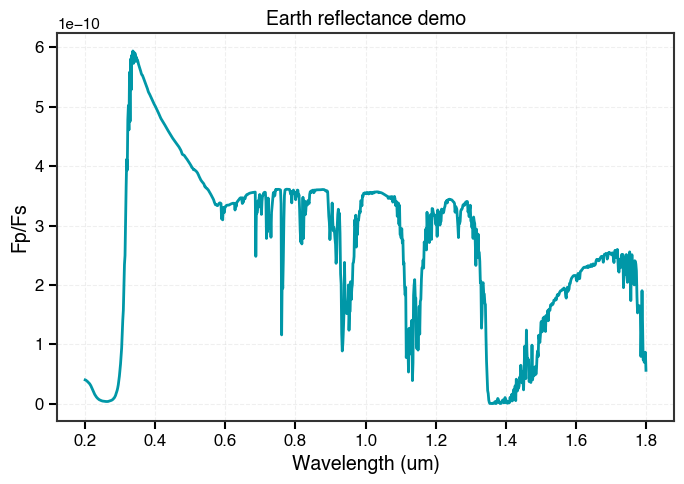

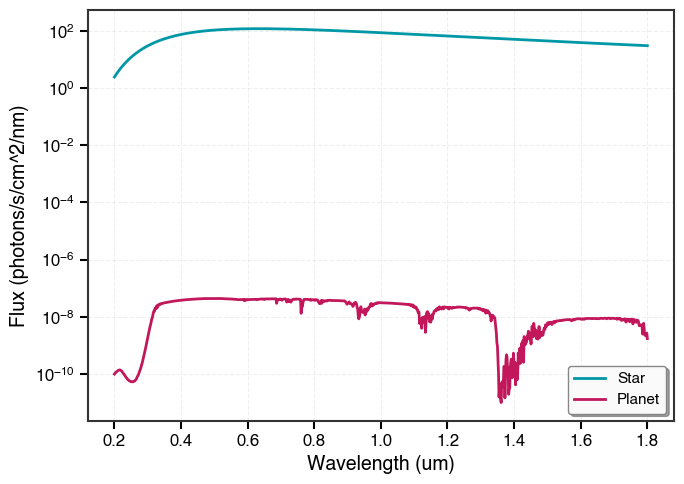

In [7]:
from synphot import SourceSpectrum, SpectralElement, Observation
from synphot.models import BlackBodyNorm1D, Empirical1D
from synphot import units as synphot_u
import astropy.units as u 
import astropy.constants as c 

def compute_blackbody_photon_flux(temp, wavelengths):
    """Generate photon flux density (photon/s/cm^2/um) for a blackbody at 1 cm^2."""
    bb = SourceSpectrum(BlackBodyNorm1D, temperature=temp)
    

    flux_photlam = bb(wavelengths)#.value * 1/(u.s * u.cm**2 * u.AA) # photons/s/cm2/A
    return flux_photlam

def compute_star_flux_observed(stellar_flux_surface, R_star, dist):
    """Scale stellar surface flux to observer distance."""
    scale = (R_star / dist)**2
    return stellar_flux_surface * scale.decompose()


# Temperature and distance to star
Tstar = 5800 * u.K
dist = 10 * u.pc

# calculate the observed Fstar
Fstar = compute_blackbody_photon_flux(Tstar, parameters["wavelength"]*u.um)
Fstar = Fstar.to(u.photon / (u.s * u.cm**2 * u.nm)) # convert to pyEdith units
Fstar_obs_10pc = Fstar * (1000*u.pc/dist)**2 # this gives the flux at 1 kpc. Scale to the distance of the star

# calculate the observed Fp/Fs
earth_wl, earth_refl = np.loadtxt("../inputs/earth_refl_demo.txt", delimiter=",").T
from scipy.interpolate import interp1d
earth_interp_func = interp1d(earth_wl, earth_refl)
FpFs = earth_interp_func(parameters["wavelength"])
Fplan_obs = Fstar_obs_10pc * FpFs

fig = plt.figure(dpi=100)
ax = plt.gca()
plt.plot(parameters["wavelength"]*u.um, FpFs, linewidth=2)
plt.xlabel("Wavelength (um)", fontsize=14, fontweight='bold')
plt.ylabel("Fp/Fs", fontsize=14, fontweight='bold')
plt.title("Earth reflectance demo", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()

fig = plt.figure(dpi=100)
ax = plt.gca()
plt.plot(parameters["wavelength"]*u.um, Fstar_obs_10pc, label="Star", linewidth=2)
plt.plot(parameters["wavelength"]*u.um, Fplan_obs, label="Planet", linewidth=2)
plt.xlabel("Wavelength (um)", fontsize=14, fontweight='bold')
plt.ylabel("Flux (photons/s/cm^2/nm)", fontsize=14, fontweight='bold')
plt.yscale("log")
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')
plt.tight_layout()



We need several more parameters to define the astrophysical scene. These include parameters related to the star, planet, zodi/exozodi...

As an example, lets take the star HD 102365. It is a sun-like star (spectral type G2V) ~10 pc away. 
It is also a Tier A target star from the NASA ExEP HWO target star list. 


In [8]:
# STAR
# distance to the system in pc
parameters["distance"] = 10. 

# radius of the star in solar radii
parameters["stellar_radius"] = 1. 

# Fstar modeled as a blackbody (see above)
parameters["Fstar_10pc"] = Fstar_obs_10pc.value 

# PLANET
# planetary separation in arcsec
parameters["separation"] = 0.1 

#Fp/Fs from Earth template (see above)
parameters["Fp/Fs"] = FpFs 

# SCENE
# number of zodis for exozodi estimate
parameters["nzodis"] = 1. 

# approximate ra and dec of HD 102365. WARNING: do not use these numbers for science.
parameters["ra"] = 176.6292  
parameters["dec"] = -40.5003 

# perfect exozodi subtraction 
parameters["ez_PPF"] = np.inf 



With these parameters, we can populate the AstrophysicalScene class and regrid the spectra to the wavelength points specified by the filter.

In [9]:
scene = pE.AstrophysicalScene()
# Load the parameters
scene.load_configuration(parameters)
# Calculate zodi/exozodi
scene.calculate_zodi_exozodi(parameters)
# Regrid spectra to wavelength grid
scene.regrid_spectra(observation) 
#Validate
scene.validate_configuration()

 

[pyEDITH] INFO [2026-09-17 10:26:24,865] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] WARNING [2026-09-17 10:26:24,866] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] INFO [2026-09-17 10:26:24,868] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] WARNING [2026-09-17 10:26:24,868] `FstarV_10pc` not specified in parameters. Calculating internally...


[pyEDITH] WARNING [2026-09-17 10:26:24,869] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


...

[pyEDITH] INFO [2026-09-17 10:26:24,889] 'Fp_over_Fs' has length 1000 but the resolved wavelength grid has length 98. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:24,894] 'Fs_over_F0' has length 1000 but the resolved wavelength grid has length 98. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:24,898] 'ez_PPF' has length 1000 but the resolved wavelength grid has length 98. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:24,902] 'mag' has length 1000 but the resolved wavelength grid has length 98. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:24,907] 'deltamag' has length 1000 but the resolved wavelength grid has length 98. Rebinning...


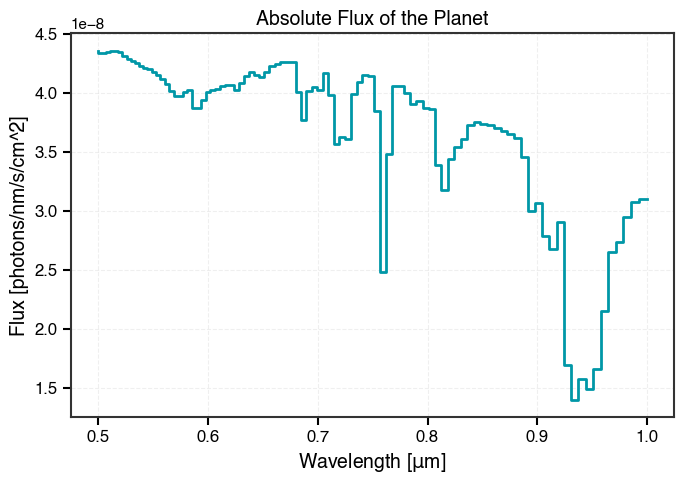

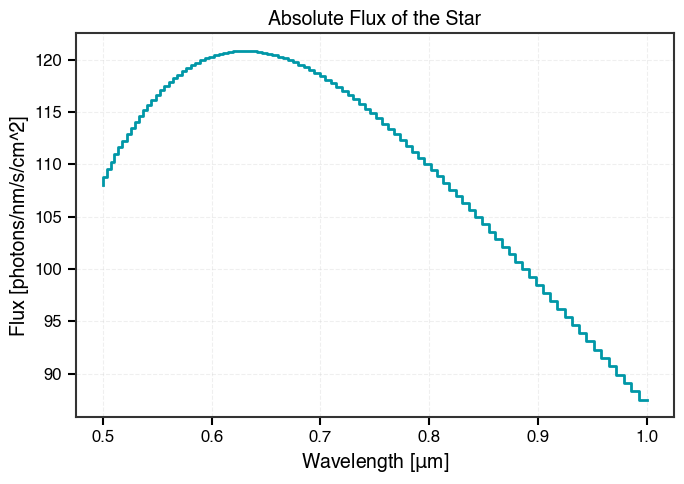

In [10]:
plt.figure(dpi=100)
ax = plt.gca()
plt.step(observation.wavelength, (getattr(scene, "Fs_over_F0")*getattr(scene, "F0")*getattr(scene, "Fp_over_Fs")), linewidth=2, color=colors.cyan)
plt.xlabel(r"Wavelength [$\mathrm{\mu}$m]", fontsize=14, fontweight='bold')
plt.ylabel("Flux [photons/nm/s/cm^2]", fontsize=14, fontweight='bold')
plt.title("Absolute Flux of the Planet")
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()

plt.figure(dpi=100)
ax = plt.gca()
plt.step(observation.wavelength, (getattr(scene, "Fs_over_F0")*getattr(scene, "F0")), linewidth=2, color=colors.cyan)
plt.xlabel(r"Wavelength [$\mathrm{\mu}$m]", fontsize=14, fontweight='bold')
plt.ylabel("Flux [photons/nm/s/cm^2]", fontsize=14, fontweight='bold')
plt.title("Absolute Flux of the Star")
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()


### 1.1.3 Observatory

Set up the observatory: telescope, coronagraph, detector.
This compiles the telescope, coronagraph, and detector and places them all in a single object. 
These parameters mostly come from the EAC YAML files, but we have to specify a few:


In [11]:
# tells ETC to use EAC1 yaml files throughputs
parameters["observatory_preset"] = "EAC1"

# extra throughput of the IFS 
parameters["IFS_eff"]  = 1.

# number of detector pixels per spectral bin
parameters["npix_multiplier"] =1.

# post processing factor (30 is a good realistic value)
parameters["noisefloor_PPF"] = 30 
     
# Where to truncate the PSF (30% of the maximum value)              
parameters["psf_trunc_ratio"] = 0.3         


In [12]:
observatory_config = pE.parse_input.get_observatory_config(parameters)
observatory = pE.Observatory()
observatory.create_observatory(observatory_config)
observatory.load_configuration(
     parameters, observation, scene
)
observatory.validate_configuration()

[pyEDITH] INFO [2026-09-17 10:26:25,035] Observatory Configuration:


[pyEDITH] INFO [2026-09-17 10:26:25,036]   Using preset: EAC1


[pyEDITH] INFO [2026-09-17 10:26:25,036] 


[pyEDITH] WARNING [2026-09-17 10:26:25,036] Coronagraph 'eac1_aavc_2d' not found locally. Attempting to fetch from remote database...


[yippy] INFO [2026-09-17 10:26:25,036] Fetching YIP 'eac1_aavc_2d' (cache: /Users/ealei/Library/Caches/yippy)


...

[pyEDITH] WARNING [2026-09-17 10:26:25,916] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] WARNING [2026-09-17 10:26:25,916] IFS_eff should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] INFO [2026-09-17 10:26:25,916] Calculating optics throughput from EAC YAML files...


[pyEDITH] INFO [2026-09-17 10:26:25,917] 'ifs_eff' has length 1000 but the resolved wavelength grid has length 98. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:25,917] Calculating epswarmTrcold as 1 - optics throughput...


### 1.2 Running the ETC
We can now calculate the exposure time for the desired SNR in each spectral bin. This calculates the exposure time necessary for each spectral bin to reach the desired SNR (7). After running, the calculated exposure times will be an attribute (`exptime`) of the pyEDITH object. 

In [13]:
pE.calculate_exposure_time_or_snr(observation, scene, observatory)

Let's plot it:

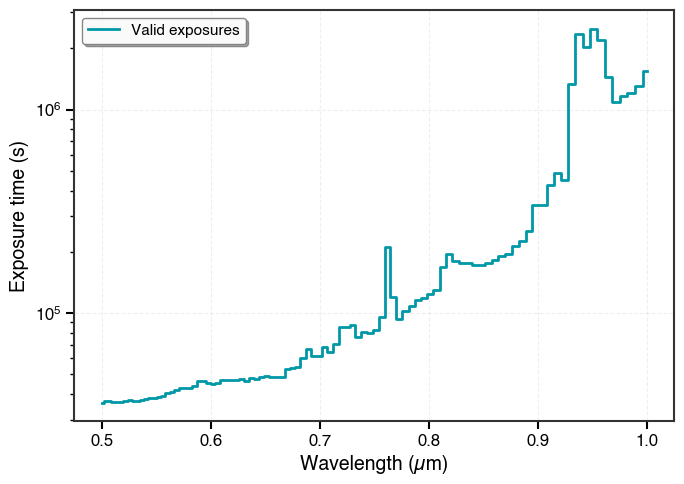

In [14]:
plt.figure(dpi=100)
ax = plt.gca()

# Plot finite exposure times
finite_mask = np.isfinite(observation.exptime)
plt.step(observation.wavelength[finite_mask], observation.exptime[finite_mask],
         where="mid", linewidth=2, color=colors.cyan, label='Valid exposures')

# Plot infinite exposure times
inf_mask = np.isinf(observation.exptime)
if np.any(inf_mask):
    max_finite = np.max(observation.exptime[finite_mask])
    plt.scatter(observation.wavelength[inf_mask],
                max_finite * np.ones_like(observation.wavelength[inf_mask]),
                marker="x", color=colors.red, s=100, linewidths=2.5,
                label='Infinite exposures', zorder=5)

plt.xlabel("Wavelength (µm)", fontsize=14, fontweight='bold')
plt.ylabel("Exposure time (s)", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
plt.yscale("log")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')
plt.tight_layout()


A more useful functionality for the observer is to calculate the SNR you get for each spectral bin when you give it an exposure time. To do this, we need to specify a different parameter called `obstime`. This is the exposure time at a reference lambda that will drive the observation. We can take one of the exposure times calculated above.

In [15]:
# Given this reference lambda, define the target obstime
ref_lam = 0.5*u.um
ind_reflam = np.argmin(np.abs(observation.wavelength - ref_lam))
observation.obstime = observation.exptime[ind_reflam] # seconds

# Calculate the SNR for all bins
pE.calculate_exposure_time_or_snr(observation, scene, observatory, mode="signal_to_noise")


Let's plot it:

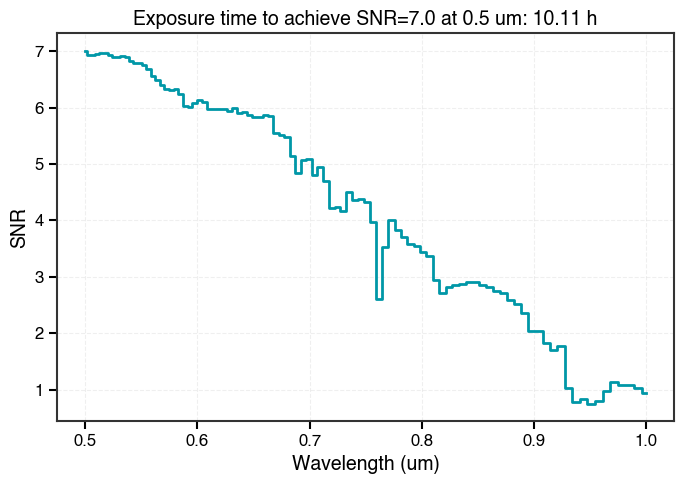

In [16]:
plt.figure(dpi=100)
ax = plt.gca()
plt.step(observation.wavelength, observation.fullsnr, where="mid", linewidth=2, color=colors.cyan)
plt.title(f"Exposure time to achieve SNR={parameters['snr'][0]} at {ref_lam}: {observation.obstime.to(u.hr).round(2)}", fontsize=14, fontweight='bold')
plt.ylabel("SNR", fontsize=14, fontweight='bold')
plt.xlabel("Wavelength (um)", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()


### 1.3 Multiple Filters

Now let's say you want to calculate different exposure times for more than one spectral channel. This is how to do it with the ETC:

In [17]:
#Define a list of filters and parse them
parameters['filter_list']=[pE.Filter('VIS',low=0.4,high=1,resolution=140,type='IFS'),
                           pE.Filter('NIR',low=1.,high=1.8,resolution=70,type='IFS'),]
parsed_filters=pE.parse_input.parse_filters(parameters)


There is no limit to the number of filters you can define. For example, you could define multiple filters within the visible channel, as well as choosing overlapping filters, or filters that don't cover the whole space.
We can now calculate the exposure time for each filter like this:

In [18]:

results = {}
validation_variables = {}
# Loop by filter
for f in parsed_filters:
    print("Running pyEDITH for Filter: " + f.name)
    # Define Observation and load relevant parameters
    observation = pE.Observation()
    observation.load_configuration(parameters, filter=f)
    observation.set_output_arrays()
    observation.validate_configuration()

    # Define Astrophysical Scene and load relevant parameters,
    # then calculate zodi/exozodi
    scene = pE.AstrophysicalScene()
    scene.load_configuration(parameters)
    scene.calculate_zodi_exozodi(parameters)
    scene.validate_configuration()
    scene.regrid_spectra(observation)

    # Create and configure Observatory
    observatory_config = pE.parse_input.get_observatory_config(parameters)
    observatory = pE.Observatory()
    observatory.create_observatory(observatory_config)
    observatory.load_configuration(parameters, observation, scene)
    observatory.validate_configuration()

    # EXPOSURE TIME CALCULATION
    pE.calculate_exposure_time_or_snr(
        observation,
        scene,
        observatory,
        mode="exposure_time",
    )

    results[f.name] = {
        "wavelength": observation.wavelength,
        "exposure_time": observation.exptime,
    }
    validation_variables[f.name] = observation.validation_variables



[pyEDITH] WARNING [2026-09-17 10:26:26,151] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] WARNING [2026-09-17 10:26:26,151] IFS_eff should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] INFO [2026-09-17 10:26:26,152] 'snr' has length 1000 but the resolved wavelength grid has length 129. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:26,154] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] WARNING [2026-09-17 10:26:26,154] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


...

[pyEDITH] WARNING [2026-09-17 10:26:26,872] IFS_eff should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] INFO [2026-09-17 10:26:26,872] Calculating optics throughput from EAC YAML files...


[pyEDITH] INFO [2026-09-17 10:26:26,872] 'ifs_eff' has length 1000 but the resolved wavelength grid has length 42. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:26,873] Calculating epswarmTrcold as 1 - optics throughput...


[pyEDITH] ERROR [2026-09-17 10:26:26,895] Count rate of the planet smaller than the noise floor for one or more wavelength channels. Hardcoded infinity results.


Let's plot it:

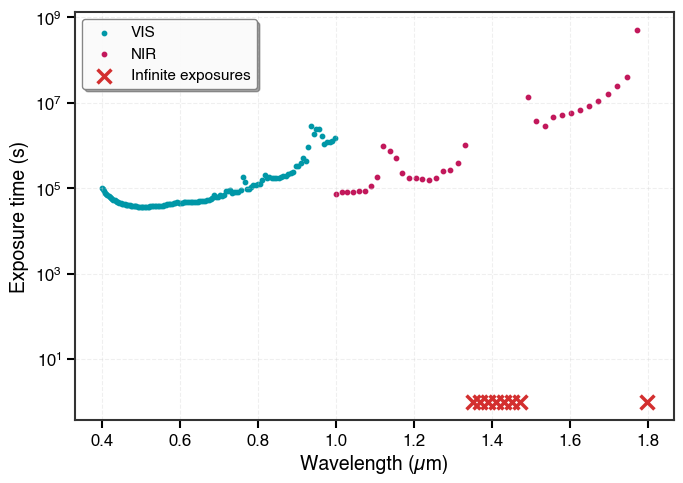

In [19]:
plt.figure(dpi=100)
ax = plt.gca()

# Plot finite exposure times
for f in parsed_filters:
    # Plot finite exposure times
    finite_mask = np.isfinite(results[f.name]['exposure_time'])
    plt.scatter(results[f.name]['wavelength'][finite_mask], results[f.name]['exposure_time'][finite_mask],
        label=f.name,s=10)
    # Plot infinite exposure times
    inf_mask = np.isinf(results[f.name]['exposure_time'])
    if np.any(inf_mask):
        max_finite = np.mean(results[f.name]['exposure_time'])
        plt.scatter(results[f.name]['wavelength'][inf_mask],
                     np.ones_like(results[f.name]['wavelength'][inf_mask]),
                    marker="x", color=colors.red, s=100, linewidths=2.5,
                    label='Infinite exposures', zorder=5)


# Plot infinite exposure times

plt.xlabel("Wavelength (µm)", fontsize=14, fontweight='bold')
plt.ylabel("Exposure time (s)", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
plt.yscale("log")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')
plt.tight_layout()

We can now select a specific reference wavelength range to extrapolate the exposure time needed to achieve SNR=7, then we can calculate how the SNR would be in the whole channel for the desired time.

[pyEDITH] WARNING [2026-09-17 10:26:26,998] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] WARNING [2026-09-17 10:26:26,998] IFS_eff should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] INFO [2026-09-17 10:26:26,999] 'snr' has length 1000 but the resolved wavelength grid has length 129. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:27,001] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] WARNING [2026-09-17 10:26:27,001] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


...

[pyEDITH] WARNING [2026-09-17 10:26:27,709] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] WARNING [2026-09-17 10:26:27,709] IFS_eff should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] INFO [2026-09-17 10:26:27,709] Calculating optics throughput from EAC YAML files...


[pyEDITH] INFO [2026-09-17 10:26:27,710] 'ifs_eff' has length 1000 but the resolved wavelength grid has length 42. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:27,710] Calculating epswarmTrcold as 1 - optics throughput...


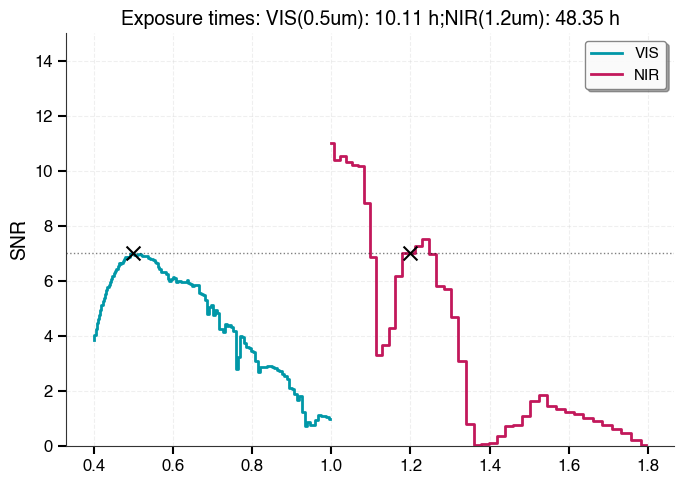

In [20]:
# Define reference wavelengths (in microns) for each spectral channel
# These wavelengths will be used to calculate exposure times for each channel
ref_lams = [ 0.5, 1.2] 

# # Run the ETC calculation separately for each spectral channel
snr_arrs = {}  # Store SNR arrays for each channel
obstimes=[] #saving observation times for plotting
validation_variables={}

for i,lam in enumerate(ref_lams):

    f=parsed_filters[i]
    # Validate that reference wavelengths are within their respective channel boundaries
    assert f.contains(lam *u.um)
    # Find the index of the wavelength grid point closest to the reference wavelength
    ind_reflam = np.argmin(np.abs(results[f.name]['wavelength'] - lam*u.um))
    obstime=results[f.name]['exposure_time'][ind_reflam] 
    obstimes.append(obstime)

    # Define Observation and load relevant parameters
    observation = pE.Observation()
    observation.load_configuration(parameters, filter=f)
    observation.set_output_arrays()
    observation.validate_configuration()
    observation.obstime=obstime

    # Define Astrophysical Scene and load relevant parameters,
    # then calculate zodi/exozodi
    scene = pE.AstrophysicalScene()
    scene.load_configuration(parameters)
    scene.calculate_zodi_exozodi(parameters)
    scene.validate_configuration()
    scene.regrid_spectra(observation)

    # Create and configure Observatory
    observatory_config = pE.parse_input.get_observatory_config(parameters)
    observatory = pE.Observatory()
    observatory.create_observatory(observatory_config)
    observatory.load_configuration(parameters, observation, scene)
    observatory.validate_configuration()

    # EXPOSURE TIME CALCULATION
    pE.calculate_exposure_time_or_snr(
        observation,
        scene,
        observatory,
        mode="signal_to_noise",
    )

    snr_arrs[f.name] = {
        "wavelength": observation.wavelength,
        "snr": observation.fullsnr,
    }

    validation_variables[f.name] = observation.validation_variables

fig = plt.figure()

# Initialize an array to hold the concatenated SNR values from all channels
snr_concat_arr = np.empty(len(observation.wavelength))

# Plot the SNR for each spectral channel in the top subplot
for f in parsed_filters:
    
    plt.step(snr_arrs[f.name]['wavelength'], snr_arrs[f.name]['snr'], label=f.name, where="mid", linewidth=2)

plt.scatter(ref_lams, [7,7], color="k", marker="x", zorder=10, s=100)
plt.axhline(7, color="k", ls=":", alpha=0.5, linewidth=1)
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
               framealpha=0.95, edgecolor='gray')
plt.ylabel("SNR", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

exptime_text = f"VIS({ref_lams[0]}um): {obstimes[0].to(u.hr).round(2)};NIR({ref_lams[1]}um): {obstimes[1].to(u.hr).round(2)}"
plt.title( f"Exposure times: {exptime_text}")
plt.ylim(0,15)


plt.tight_layout()


## 2. Visualization

Every variable is stored in either of the defined classes (see [Glossary](glossary.md)). This means that we can easily plot any variable we need.

Throughput:

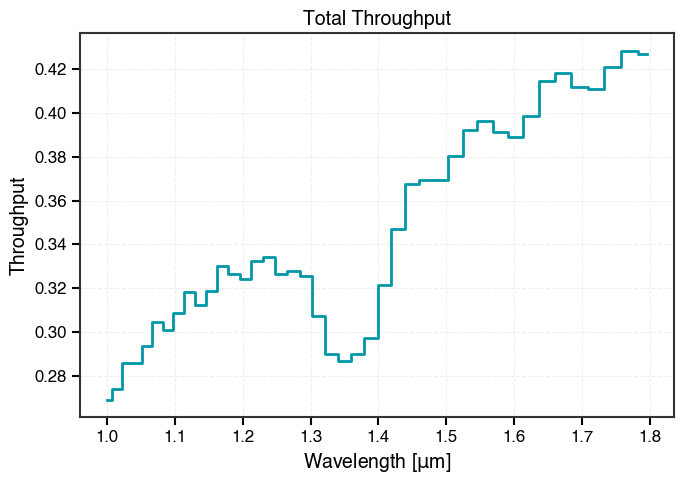

In [21]:
plt.figure(dpi=100)
ax = plt.gca()
plt.step(observation.wavelength, observatory.total_throughput, where="mid",
         linewidth=2, color=colors.cyan)
plt.xlabel(r"Wavelength [$\mathrm{\mu}$m]", fontsize=14, fontweight='bold')
plt.ylabel("Throughput", fontsize=14, fontweight='bold')
plt.title("Total Throughput")
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()


Coronagraph response maps:

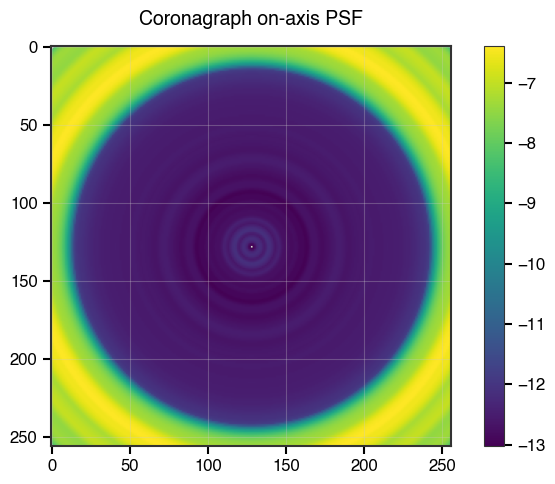

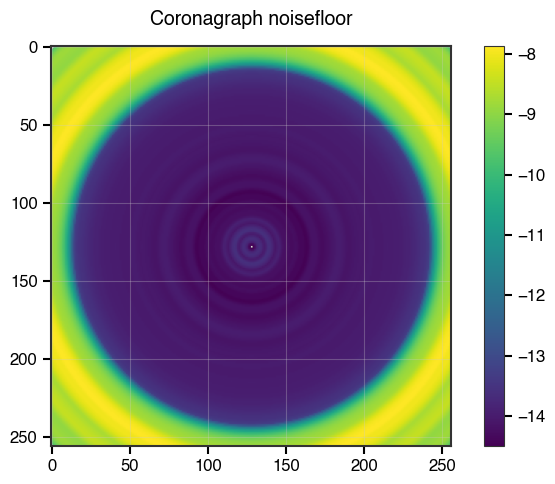

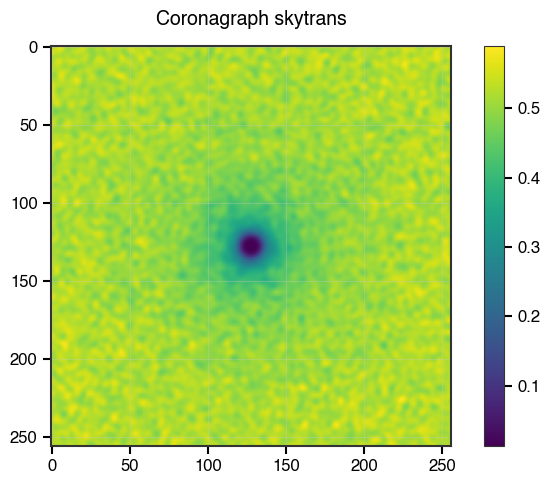

In [22]:
plt.figure(dpi=100)
ax = plt.gca()
data1 = np.log10(observatory.coronagraph.Istar)
plt.imshow(data1)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=12, width=1.5, length=6)
plt.title("Coronagraph on-axis PSF", fontsize=14, fontweight='bold', pad=15)
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.clim(np.nanmin(data1), np.nanmax(data1))
plt.tight_layout()

plt.figure(dpi=100)
ax = plt.gca()
data2 = np.log10(observatory.coronagraph.noisefloor)
plt.imshow(data2)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=12, width=1.5, length=6)
plt.title("Coronagraph noisefloor", fontsize=14, fontweight='bold', pad=15)
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.clim(np.nanmin(data2), np.nanmax(data2))
plt.tight_layout()

plt.figure(dpi=100)
ax = plt.gca()
data3 = observatory.coronagraph.skytrans
plt.imshow(data3)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=12, width=1.5, length=6)
plt.title("Coronagraph skytrans", fontsize=14, fontweight='bold', pad=15)
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.clim(np.nanmin(data3), np.nanmax(data3))
plt.tight_layout()



`pyEDITH` also has a specific function to synthesize observations:


[pyEDITH] WARNING [2026-09-17 10:26:28,159] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] WARNING [2026-09-17 10:26:28,160] IFS_eff should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] INFO [2026-09-17 10:26:28,160] 'snr' has length 1000 but the resolved wavelength grid has length 129. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:28,162] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] WARNING [2026-09-17 10:26:28,163] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


...

[pyEDITH] WARNING [2026-09-17 10:26:28,878] ez_PPF should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] WARNING [2026-09-17 10:26:28,878] IFS_eff should be a list of length 1000. pyEDITH will create one assuming the input value for all the elements of the list.


[pyEDITH] INFO [2026-09-17 10:26:28,878] Calculating optics throughput from EAC YAML files...


[pyEDITH] INFO [2026-09-17 10:26:28,878] 'ifs_eff' has length 1000 but the resolved wavelength grid has length 42. Rebinning...


[pyEDITH] INFO [2026-09-17 10:26:28,879] Calculating epswarmTrcold as 1 - optics throughput...


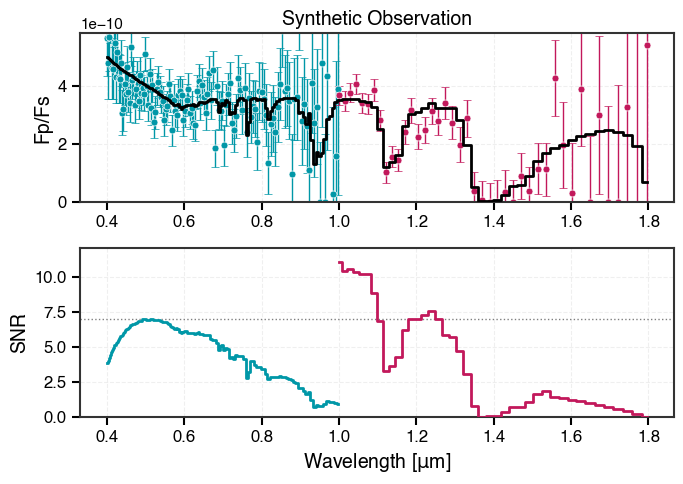

In [23]:

import matplotlib.pyplot as plt

fig = plt.figure(dpi=100)
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)

for i,lam in enumerate(ref_lams):

    f=parsed_filters[i]
    # Validate that reference wavelengths are within their respective channel boundaries
    assert f.contains(lam *u.um)
    # Find the index of the wavelength grid point closest to the reference wavelength
    ind_reflam = np.argmin(np.abs(results[f.name]['wavelength'] - lam*u.um))
    obstime=results[f.name]['exposure_time'][ind_reflam] 
    obstimes.append(obstime)

    # Define Observation and load relevant parameters
    observation = pE.Observation()
    observation.load_configuration(parameters, filter=f)
    observation.set_output_arrays()
    observation.validate_configuration()
    observation.obstime=obstime

    # Define Astrophysical Scene and load relevant parameters,
    # then calculate zodi/exozodi
    scene = pE.AstrophysicalScene()
    scene.load_configuration(parameters)
    scene.calculate_zodi_exozodi(parameters)
    scene.validate_configuration()
    scene.regrid_spectra(observation)

    # Create and configure Observatory
    observatory_config = pE.parse_input.get_observatory_config(parameters)
    observatory = pE.Observatory()
    observatory.create_observatory(observatory_config)
    observatory.load_configuration(parameters, observation, scene)
    observatory.validate_configuration()

    # EXPOSURE TIME CALCULATION
    pE.calculate_exposure_time_or_snr(
        observation,
        scene,
        observatory,
        mode="signal_to_noise",
    )

    obs, noise = pE.utils.synthesize_observation(observation.fullsnr,
                                             scene, 
                                             random_seed=42, # seed defaults to None
                                             set_below_zero=0., # if the fake data falls below zero, set the data point as this. default = NaN
                                             )

    ax1.step(observation.wavelength, scene.Fp_over_Fs, color="k", where="mid", zorder=10, linewidth=2)
    ax1.errorbar(observation.wavelength, obs, yerr=noise, fmt="o", 
             markersize=5,  markeredgecolor='white',
             markeredgewidth=0.5, elinewidth=1, capsize=3)

    ax2.step(observation.wavelength, observation.fullsnr, where="mid", zorder=10, linewidth=2)

ax1.set_ylabel("Fp/Fs", fontsize=14, fontweight='bold')
ax1.set_title("Synthetic Observation", fontsize=14, fontweight='bold')

ax1.set_ylim(0, np.median(scene.Fp_over_Fs) + 1.5 * np.median(scene.Fp_over_Fs))
ax1.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
ax1.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)



plt.xlabel(r"Wavelength [$\mathrm{\mu}$m]", fontsize=14, fontweight='bold')
ax2.set_ylabel("SNR", fontsize=14, fontweight='bold')
ax2.axhline(7, color="k", ls=":", linewidth=1,alpha=0.5)
ax2.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
ax2.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax2.set_ylim(0,12)
plt.tight_layout()


Photon counts can also be plotted. For this, we can either look into the `validation_variables` or use a logfile that is automatically created when running with logging == DEBUG, `photon_counts.pk`:

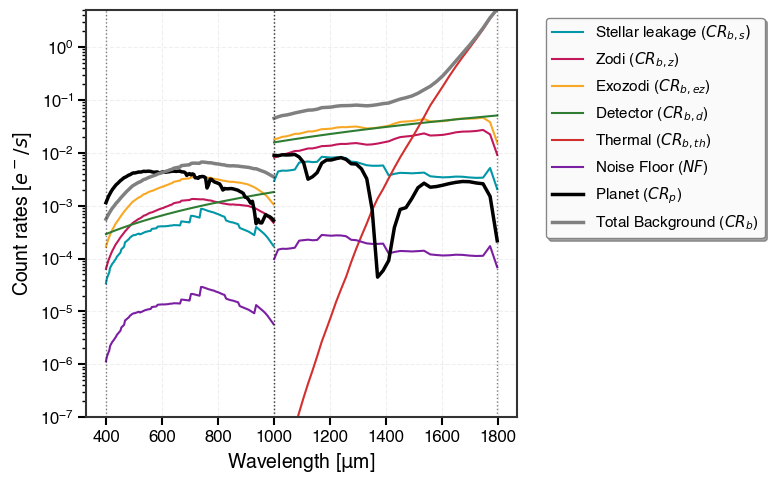

In [24]:
import matplotlib.pyplot as plt

name_mapping = {
    "CRp": r"Planet ($CR_p$)",
    "CRbs": r"Stellar leakage ($CR_{b,s})$",
    "CRbz": r"Zodi ($CR_{b,z}$)",
    "CRbez": r"Exozodi ($CR_{b,ez}$)",
    "CRbth": r"Thermal ($CR_{b,th}$)",
    "CRbd": r"Detector ($CR_{b,d}$)",
    "CRnf": r"Noise Floor ($NF$)",
    "CRb": r"Total Background ($CR_b$)"
}


fig = plt.figure(figsize=(8, 5), dpi=100)
ax = plt.gca()
for f in parsed_filters:
    for key in ['CRbs','CRbz','CRbez','CRbd','CRbth','CRnf']:
        label = name_mapping.get(key, key) if f==parsed_filters[0] else ''
        plt.plot(validation_variables[f.name]['wavelength'], validation_variables[f.name][key], label=label, lw=1.5)
    #Special treatment for CRp and CRb
    label = name_mapping.get('CRp', 'CRp')  if f==parsed_filters[0] else ''
    plt.plot(validation_variables[f.name]['wavelength'], validation_variables[f.name]['CRp'], label=label, lw=2.5,color='k')    
    label = name_mapping.get('CRb', 'CRb')  if f==parsed_filters[0] else ''
    plt.plot(validation_variables[f.name]['wavelength'], validation_variables[f.name]['CRb'], label=label, lw=2.5,color='gray') 

    # vertical edges to show the filter edges
    wavelengths = validation_variables[f.name]['wavelength'].value
    plt.axvline(wavelengths.min(), color='black', linestyle=':', linewidth=1, alpha=0.5)
    plt.axvline(wavelengths.max(), color='black', linestyle=':', linewidth=1, alpha=0.5)

plt.yscale("log")
plt.ylim(1e-7, 5e0)
plt.ylabel("Count rates [$e^-/s$]", fontsize=14, fontweight='bold')
plt.xlabel(r"Wavelength [$\mathrm{\mu}$m]", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, 
          frameon=True, shadow=True, fancybox=True, framealpha=0.95, 
          edgecolor='gray', ncol=1)       
# plt.title("Count Rates", fontsize=14, fontweight='bold')
plt.tight_layout()
